Using device: cuda
Mounted at /content/drive

Training with regularization λ = 1e-05
Epoch [1/26], Total Loss: 3749.2236
Epoch [2/26], Total Loss: 3224.3626
Epoch [3/26], Total Loss: 2819.7631
Epoch [4/26], Total Loss: 2490.9139
Epoch [5/26], Total Loss: 2225.2807
Epoch [6/26], Total Loss: 2010.8271
Epoch [7/26], Total Loss: 1838.6458
Epoch [8/26], Total Loss: 1696.7513
Epoch [9/26], Total Loss: 1579.4440
Epoch [10/26], Total Loss: 1478.2178
Epoch [11/26], Total Loss: 1393.2556
Epoch [12/26], Total Loss: 1318.2331
Epoch [13/26], Total Loss: 1251.7788
Epoch [14/26], Total Loss: 1192.8348
Epoch [15/26], Total Loss: 1138.9062
Epoch [16/26], Total Loss: 1090.8266
Epoch [17/26], Total Loss: 1045.1925
Epoch [18/26], Total Loss: 1004.7848
Epoch [19/26], Total Loss: 966.5695
Epoch [20/26], Total Loss: 930.3843
Epoch [21/26], Total Loss: 900.9084
Epoch [22/26], Total Loss: 871.2797
Epoch [23/26], Total Loss: 842.1373
Epoch [24/26], Total Loss: 815.7807
Epoch [25/26], Total Loss: 793.0258
Epoch 

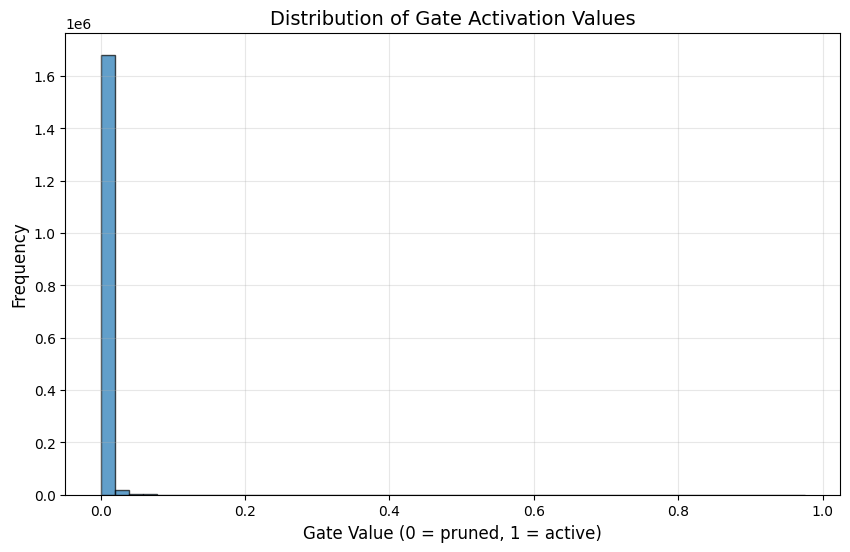

In [5]:
# -*- coding: utf-8 -*-
"""PrunableCIFAR10_Optimized.ipynb

Automatically generated by Colab.
"""

# Cell 1: Setup and imports
!pip install torchvision

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt

# Device configuration
compute_device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {compute_device}")

# Cell 2: Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Cell 3: Save path for best model
checkpoint_path = "/content/drive/MyDrive/optimized_model_weights.pth"

# Cell 4: Custom Linear Layer with Learnable Gates
class AdaptiveLinear(nn.Module):
    def __init__(self, input_dim, output_dim):
        super(AdaptiveLinear, self).__init__()
        # Weight initialization
        self.weight_matrix = nn.Parameter(torch.randn(output_dim, input_dim) * 0.02)
        self.bias_vector = nn.Parameter(torch.zeros(output_dim))

        # Gate scores (trainable parameters)
        self.gate_logits = nn.Parameter(torch.randn(output_dim, input_dim))

    def forward(self, x):
        # Compute gate probabilities between 0 and 1
        gate_probs = torch.sigmoid(self.gate_logits)
        # Apply gates to weights
        masked_weights = self.weight_matrix * gate_probs
        # Linear transformation
        return torch.matmul(x, masked_weights.t()) + self.bias_vector

    def get_gate_values(self):
        return torch.sigmoid(self.gate_logits)

# Cell 5: Multi-Layer Perceptron with Prunable Layers
class AdaptiveMLP(nn.Module):
    def __init__(self):
        super(AdaptiveMLP, self).__init__()
        self.flatten_input = nn.Flatten()

        # Fully connected layers with adaptive pruning
        self.layer1 = AdaptiveLinear(32*32*3, 512)   # Input -> Hidden1
        self.layer2 = AdaptiveLinear(512, 256)       # Hidden1 -> Hidden2
        self.layer3 = AdaptiveLinear(256, 10)        # Hidden2 -> Output

        self.activation = nn.ReLU()

    def forward(self, x):
        x = self.flatten_input(x)
        x = self.activation(self.layer1(x))
        x = self.activation(self.layer2(x))
        x = self.layer3(x)
        return x

    def collect_all_gates(self):
        return [
            self.layer1.get_gate_values(),
            self.layer2.get_gate_values(),
            self.layer3.get_gate_values()
        ]

# Cell 6: Data Loading and Preprocessing
transform_pipeline = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# Training dataset
train_dataset = torchvision.datasets.CIFAR10(
    root='./data', train=True, download=True, transform=transform_pipeline
)
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=128, shuffle=True)

# Testing dataset
test_dataset = torchvision.datasets.CIFAR10(
    root='./data', train=False, download=True, transform=transform_pipeline
)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=128, shuffle=False)

# Cell 7: Sparsity Regularization Loss
def compute_sparsity_penalty(model):
    total_gate_sum = 0
    for gate_tensor in model.collect_all_gates():
        total_gate_sum += torch.sum(gate_tensor)
    return total_gate_sum

# Cell 8: Training Function
def run_training(regularization_strength=1e-4, num_epochs=26):
    # Initialize model
    model = AdaptiveMLP().to(compute_device)

    # Loss function and optimizer
    loss_fn = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    # Training loop
    for epoch_idx in range(num_epochs):
        model.train()
        epoch_loss = 0.0

        for batch_images, batch_labels in train_loader:
            batch_images, batch_labels = batch_images.to(compute_device), batch_labels.to(compute_device)

            optimizer.zero_grad()

            # Forward pass
            predictions = model(batch_images)

            # Classification loss
            cls_loss = loss_fn(predictions, batch_labels)

            # Sparsity regularization
            sparsity_penalty = compute_sparsity_penalty(model)

            # Total loss
            total_loss = cls_loss + regularization_strength * sparsity_penalty

            # Backward pass
            total_loss.backward()
            optimizer.step()

            epoch_loss += total_loss.item()

        print(f"Epoch [{epoch_idx+1}/{num_epochs}], Total Loss: {epoch_loss:.4f}")

    return model

# Cell 9: Evaluation Function
def evaluate_model(model):
    model.eval()
    correct_predictions = 0
    total_samples = 0

    # Accuracy calculation
    with torch.no_grad():
        for batch_images, batch_labels in test_loader:
            batch_images, batch_labels = batch_images.to(compute_device), batch_labels.to(compute_device)
            outputs = model(batch_images)

            _, predicted_classes = torch.max(outputs, 1)
            total_samples += batch_labels.size(0)
            correct_predictions += (predicted_classes == batch_labels).sum().item()

    accuracy_percent = 100 * correct_predictions / total_samples

    # Sparsity calculation
    total_weights_count = 0
    near_zero_weights = 0

    for gate_values in model.collect_all_gates():
        total_weights_count += gate_values.numel()
        near_zero_weights += torch.sum(gate_values < 1e-2).item()

    sparsity_percent = 100 * near_zero_weights / total_weights_count

    return accuracy_percent, sparsity_percent

# Cell 10: Hyperparameter Search
lambda_values = [1e-5, 1e-4, 5e-4]
experiment_results = []
highest_accuracy = 0
best_model_save_path = "/content/drive/MyDrive/best_model.pth"

for current_lambda in lambda_values:
    print(f"\n{'='*50}")
    print(f"Training with regularization λ = {current_lambda}")
    print(f"{'='*50}")

    trained_model = run_training(regularization_strength=current_lambda)

    acc, sparsity = evaluate_model(trained_model)
    print(f"📊 Results -> Accuracy: {acc:.2f}% | Sparsity: {sparsity:.2f}%")

    experiment_results.append((current_lambda, acc, sparsity))

    # Save best performing model
    if acc > highest_accuracy:
        highest_accuracy = acc
        torch.save(trained_model.state_dict(), best_model_save_path)
        print(f"✅ New best model saved (Accuracy: {acc:.2f}%) to Google Drive!")

# Cell 11: Visualization of Gate Distributions
def visualize_gate_distribution(model):
    all_gate_values = []

    for gate_tensor in model.collect_all_gates():
        all_gate_values.extend(gate_tensor.detach().cpu().numpy().flatten())

    plt.figure(figsize=(10, 6))
    plt.hist(all_gate_values, bins=50, edgecolor='black', alpha=0.7)
    plt.title("Distribution of Gate Activation Values", fontsize=14)
    plt.xlabel("Gate Value (0 = pruned, 1 = active)", fontsize=12)
    plt.ylabel("Frequency", fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.show()

# Optional: Visualize gates for the best model
# Load best model and visualize
best_model = AdaptiveMLP().to(compute_device)
best_model.load_state_dict(torch.load(best_model_save_path))
visualize_gate_distribution(best_model)